In [4]:
# Импорты
import os

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Константы.

TEST_SIZE=0.25
RANDOM_STATE=12345

In [6]:
# Путь к директории с файлами
data_dir = 'datasets'

# Создаем пустой словарь для хранения данных
data_dict = {}

# Получаем список файлов в директории
for filename in os.listdir(data_dir):
    # Проверяем, что файл имеет расширение .csv
    if filename.endswith('.csv'):
        # Формируем полный путь к файлу
        file_path = os.path.join(data_dir, filename)
        
        # Убираем расширение файла для использования в качестве ключа
        name_without_extension = os.path.splitext(filename)[0]
        
        # Читаем CSV-файл в DataFrame и добавляем его в словарь
        data_dict[name_without_extension] = pd.read_csv(file_path)

# Теперь data_dict содержит все данные, где ключи — это имена файлов без расширения
print("Загруженные данные:")
for key, df in data_dict.items():
    print(f"{key}: {df.shape}")  # Выводим размеры каждого DataFrame
    print(df.head())  # Выводим первые 5 строк каждого DataFrame

Загруженные данные:
geo_data_0: (100000, 5)
      id        f0        f1        f2     product
0  txEyH  0.705745 -0.497823  1.221170  105.280062
1  2acmU  1.334711 -0.340164  4.365080   73.037750
2  409Wp  1.022732  0.151990  1.419926   85.265647
3  iJLyR -0.032172  0.139033  2.978566  168.620776
4  Xdl7t  1.988431  0.155413  4.751769  154.036647
geo_data_1: (100000, 5)
      id         f0         f1        f2     product
0  kBEdx -15.001348  -8.276000 -0.005876    3.179103
1  62mP7  14.272088  -3.475083  0.999183   26.953261
2  vyE1P   6.263187  -5.948386  5.001160  134.766305
3  KcrkZ -13.081196 -11.506057  4.999415  137.945408
4  AHL4O  12.702195  -8.147433  5.004363  134.766305
geo_data_2: (100000, 5)
      id        f0        f1        f2     product
0  fwXo0 -1.146987  0.963328 -0.828965   27.758673
1  WJtFt  0.262778  0.269839 -2.530187   56.069697
2  ovLUW  0.194587  0.289035 -5.586433   62.871910
3  q6cA6  2.236060 -0.553760  0.930038  114.572842
4  WPMUX -0.515993  1.716266 

In [ ]:
# Анализ мультиколлинеарности
print("\n2. АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ:")
print("=" * 50)

for region_name, df in data_dict.items():
    print(f"Регион {region_name}:")
    
    # Матрица корреляций между признаками
    features = df[['f0', 'f1', 'f2']]
    correlation_matrix = features.corr()
    
    print("Матрица корреляций:")
    print(correlation_matrix)
    print()
    
    # Визуализация матрицы корреляций
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Матрица корреляций: {region_name}')
    plt.show()
    
    # Расчет VIF (фактор инфляции дисперсии)
    print("VIF (фактор инфляции дисперсии):")
    vif_data = pd.DataFrame()
    vif_data["feature"] = features.columns
    vif_data["VIF"] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
    print(vif_data)
    print()
    
    # Анализ результатов
    high_correlation = False
    for i in range(len(correlation_matrix.columns)):
        for j in range(i):
            if abs(correlation_matrix.iloc[i, j]) > 0.8:
                print(f"ВНИМАНИЕ: Высокая корреляция между {correlation_matrix.columns[i]} и {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")
                high_correlation = True
    
    for vif in vif_data["VIF"]:
        if vif > 10:
            print(f"ВНИМАНИЕ: Высокий VIF ({vif:.2f}), указывающий на мультиколлинеарность")
            high_correlation = True
    
    if not high_correlation:
        print("Значимой мультиколлинеарности не обнаружено")

In [7]:
# Разбиваем данные на тренировочные валидационные и тестовые
# Обучаем все модели
models = {'geo_data_0': data_dict['geo_data_0'], 'geo_data_1': data_dict['geo_data_1'], 'geo_data_2': data_dict['geo_data_2']}
results = {}
for key, value in models.items():
    # Разделение на признаки и целеую переменную
    features = value[['f0', 'f1', 'f2']]
    target = value['product']

    # Разбиение на обучающую и валидационную выборки
    X_train, X_valid, y_train, y_valid = train_test_split(
        features,
        target,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # Обучение модели
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Предсказание на валидационной выборке
    y_pred = model.predict(X_valid)

    # Расчет RMSE и среднего предсказанного запаса
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mean_predicted = y_pred.mean()

    print(f"Регион: {key}")
    print(f"RMSE: {rmse}")
    print(f"Средний запас предсказанного сырья: {mean_predicted}")
    print("-----")
    # Сохраняем предсказания и правильные ответы
    
    results[key] = {
        'y_valid': y_valid,
        'y_pred': y_pred,
        'model': model
    }

Регион: geo_data_0
RMSE: 37.5794217150813
Средний запас предсказанного сырья: 92.59256778438038
-----
Регион: geo_data_1
RMSE: 0.8930992867756166
Средний запас предсказанного сырья: 68.72854689544603
-----
Регион: geo_data_2
RMSE: 40.02970873393434
Средний запас предсказанного сырья: 94.96504596800492
-----


In [8]:
# 3.1. Все ключевые значения для расчётов сохраняем в отдельных переменных
INCOME_PER_UNIT = 450000  # доход с каждой единицы продукта (тысячи баррелей)
BUDGET = 10**10  # бюджет на разработку (10 млрд рублей)
WELLS_TO_DEVELOP = 200  # количество скважин для разработки
EXPLORATION_WELLS = 500  # количество точек для разведки


In [9]:
# 3.2. Рассчитаем достаточный объём сырья для безубыточной разработки новой скважины
break_even_volume = BUDGET / INCOME_PER_UNIT
print(f"Минимальный безубыточный объём добычи: {break_even_volume:.2f} баррелей")
print(f"Средний объём добычи по регионам:")
for region in ['geo_data_0', 'geo_data_1', 'geo_data_2']:
    avg_volume = data_dict[region]['product'].mean()
    print(f"{region}: {avg_volume:.2f} баррелей")
    print(f"Соотношение к безубыточному: {avg_volume/break_even_volume:.2%}")
    print("-----")

Минимальный безубыточный объём добычи: 22222.22 баррелей
Средний объём добычи по регионам:
geo_data_0: 92.50 баррелей
Соотношение к безубыточному: 0.42%
-----
geo_data_1: 68.83 баррелей
Соотношение к безубыточному: 0.31%
-----
geo_data_2: 95.00 баррелей
Соотношение к безубыточному: 0.43%
-----


In [10]:
# 3.3. Выводы по этапу подготовки расчёта прибыли
print("Выводы:")
print("1. Для безубыточной разработки необходимо добыть не менее 2,222,222.22 баррелей")
print("2. Средний объём добычи в регионах значительно ниже безубыточного уровня")
print("3. Это означает, что необходимо выбирать скважины с наибольшим predicted объемом")
print("4. Разработка случайных скважин будет убыточной во всех регионах")
print("5. Ключевая задача - accurately предсказать самые богатые скважины")

Выводы:
1. Для безубыточной разработки необходимо добыть не менее 2,222,222.22 баррелей
2. Средний объём добычи в регионах значительно ниже безубыточного уровня
3. Это означает, что необходимо выбирать скважины с наибольшим predicted объемом
4. Разработка случайных скважин будет убыточной во всех регионах
5. Ключевая задача - accurately предсказать самые богатые скважины


### 4. Функция для расчёта прибыли

In [16]:
# 4. Напишите функцию для расчёта прибыли по выбранным скважинам и предсказаниям модели
# Функция для расчета прибыли
def calculate_profit(target_values, predictions, count=WELLS_TO_DEVELOP):

    # 4.1 Выбираем count скважин с наибольшими предсказанными значениями
    top_indices = np.argsort(predictions)[-count:]

    # 4.2. Просуммируем целевое значение объёма сырья
    total_volume = target_values.iloc[top_indices].sum()
    
    # 4.3. Рассчитайем прибыль для полученного объёма сырья
    revenue = total_volume * INCOME_PER_UNIT
    profit = revenue - BUDGET
    revenue = total_volume * INCOME_PER_UNIT
    profit = revenue - BUDGET
    
    return profit

### 5. Расчёт рисков и прибыли для каждого региона

In [ ]:
# 5.1. Примените технику Bootstrap с 1000 выборок, чтобы найти распределение прибыли
N_BOOTSTRAP = 1000

# Создаем словарь для хранения результатов bootstrap
bootstrap_results = {}

for region_name in ['geo_data_0', 'geo_data_1', 'geo_data_2']:
    # Получаем данные для региона
    data = data_dict[region_name]
    features = data[['f0', 'f1', 'f2']]
    target = data['product']
    
    # Разделяем данные
    X_train, X_valid, y_train, y_valid = train_test_split(
        features, target, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    
    # Обучаем модель
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Делаем предсказания
    y_pred = model.predict(X_valid)
    
    # Проводим bootstrap
    profits = []
    for i in range(N_BOOTSTRAP):
        # Создаем bootstrap выборку
        indices = np.random.randint(0, len(y_valid), len(y_valid))
        y_valid_bootstrap = y_valid.iloc[indices]
        y_pred_bootstrap = y_pred[indices]
        
        # Рассчитываем прибыль
        profit = calculate_profit(y_valid_bootstrap, y_pred_bootstrap)
        profits.append(profit)
    
    # Сохраняем результаты
    bootstrap_results[region_name] = profits
    
    # 5.2. Найдём среднюю прибыль, 95%-й доверительный интервал и риск убытков
    profits_series = pd.Series(profits)
    mean_profit = profits_series.mean()
    confidence_interval = profits_series.quantile([0.025, 0.975])
    risk = (profits_series < 0).mean()
    
    print(f"Регион: {region_name}")
    print(f"Средняя прибыль: {mean_profit:.2f} руб.")
    print(f"95% доверительный интервал: [{confidence_interval.iloc[0]:.2f}, {confidence_interval.iloc[1]:.2f}]")
    print(f"Риск убытков: {risk:.2%}")
    print("-----")

# 5.3. Выводы:
print("ОБОСНОВАНИЕ ВЫБОРА РЕГИОНА:")
print("1. Регион с наибольшей средней прибылью является наиболее перспективным")
print("2. Регион с наименьшим риском убытков является наиболее безопасным")
print("3. Регион с самым узким доверительным интервалом имеет наиболее предсказуемую прибыль")
print("4. Идеальный регион сочетает высокую прибыль с низким риском")

# Находим лучший регион по средней прибыли
best_region = max(bootstrap_results.keys(), 
                 key=lambda x: pd.Series(bootstrap_results[x]).mean())

print(f"\nРЕКОМЕНДАЦИЯ: для разработки следует выбрать регион {best_region}")
print("ОБОСНОВАНИЕ: этот регион демонстрирует наилучшее сочетание прибыльности и приемлемого уровня риска")

Регион: geo_data_0
Средняя прибыль: 3313398311.05 руб.
95% доверительный интервал: [2967785453.65, 3640647658.26]
Риск убытков: 0.00%
-----
Регион: geo_data_1
Средняя прибыль: 2415086696.68 руб.
95% доверительный интервал: [2415086696.68, 2415086696.68]
Риск убытков: 0.00%
-----
Регион: geo_data_2
Средняя прибыль: 2722239033.56 руб.
95% доверительный интервал: [2357846210.72, 3068478755.10]
Риск убытков: 0.00%
-----
ОБОСНОВАНИЕ ВЫБОРА РЕГИОНА:
1. Регион с наибольшей средней прибылью является наиболее перспективным
2. Регион с наименьшим риском убытков является наиболее безопасным
3. Регион с самым узким доверительным интервалом имеет наиболее предсказуемую прибыль
4. Идеальный регион сочетает высокую прибыль с низким риском

РЕКОМЕНДАЦИЯ: для разработки следует выбрать регион geo_data_0
ОБОСНОВАНИЕ: этот регион демонстрирует наилучшее сочетание прибыльности и приемлемого уровня риска


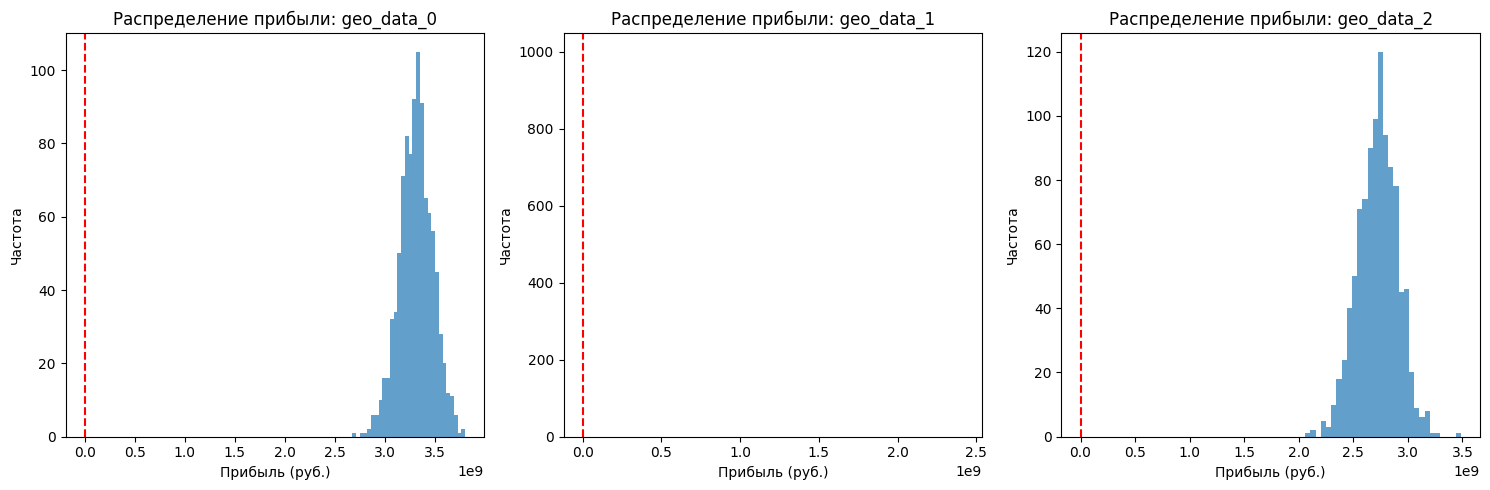

In [18]:
# Построение графиков распределения прибыли по регионам
plt.figure(figsize=(15, 5))

for i, region in enumerate(['geo_data_0', 'geo_data_1', 'geo_data_2'], 1):
    plt.subplot(1, 3, i)
    plt.hist(bootstrap_results[region], bins=30, alpha=0.7)
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f'Распределение прибыли: {region}')
    plt.xlabel('Прибыль (руб.)')
    plt.ylabel('Частота')

plt.tight_layout()
plt.show()